## Chapter 25 — Sprint Performance Prediction

In this chapter we create a small synthetic dataset of athletes and build a simple regression model to predict the next 100m sprint time.

What you'll find in the next cells:
- a synthetic dataset (if a real `df` isn't present)
- feature scaling, train/test split
- a Random Forest regressor with evaluation (MSE, R^2)
- a helper to predict a single new athlete and to save the model/scaler

Contract:
- Inputs: athlete features (age, height_cm, weight_kg, training_hours_per_week, previous_100m_best)
- Output: predicted next 100m time (seconds)

Edge cases considered: missing `df` (we generate synthetic), small dataset, and simple scaling pipeline.


### Chapter 25 — Summary & how this chapter helps

Brief problem statement

- We want to predict an athlete's next 100m sprint time from available features (age, height, weight, weekly training hours, and previous best). The goal is to provide actionable predictions for personalized training, performance monitoring, and talent identification.

How this chapter helps

- The chapter demonstrates a small end-to-end regression pipeline: dataset construction/cleaning, feature selection, scaling, model training (Random Forest), evaluation (MSE, R²), and saving a trained model for reuse. These steps map directly to the project needs: they let us produce reliable point predictions, inspect which features matter, and export models for deployment in a coaching app or analysis dashboard.

Short Python example (how to use the saved model)

```python
# Load saved model and scaler and predict for a new athlete
import joblib
import pandas as pd

feature_cols = ['age','height_cm','weight_kg','training_hours_per_week','previous_100m_best']

rf = joblib.load('chapter25_rf_model.joblib')
scaler = joblib.load('chapter25_scaler.joblib')

def predict_new_athlete(model, scaler, athlete: dict) -> float:
    df = pd.DataFrame([athlete])
    X = df[feature_cols]
    X_scaled = scaler.transform(X)
    return float(model.predict(X_scaled)[0])

example = {'age':22, 'height_cm':178, 'weight_kg':72, 'training_hours_per_week':10, 'previous_100m_best':11.4}
print('Predicted next 100m time (s):', predict_new_athlete(rf, scaler, example))

# Quick interpretability: feature importances from the Random Forest
for name, imp in zip(feature_cols, rf.feature_importances_):
    print(f'{name}: {imp:.3f}')
```

Notes and next improvements

- This example is intentionally simple. Next steps could include cross-validation, hyperparameter tuning, prediction intervals (e.g., using quantile forests or conformal prediction), more features (GPS-derived metrics, fatigue/load metrics), and model explainability (SHAP) for coach-facing insights.

MSE: 0.0240, R^2: 0.7361
age: 0.029
height_cm: 0.033
weight_kg: 0.048
training_hours_per_week: 0.335
previous_100m_best: 0.556


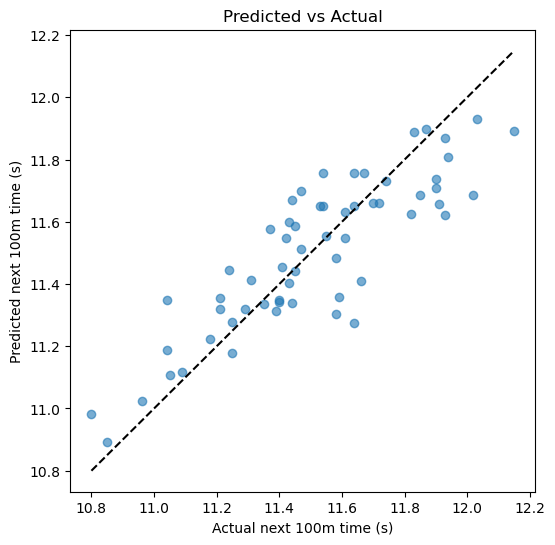

In [12]:
# Train & evaluate model
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Features defined for reuse by other cells
feature_cols = ['age','height_cm','weight_kg','training_hours_per_week','previous_100m_best']

# Assume `df` created in previous cell; if not, create synthetic small dataset
try:
    df
except NameError:
    np.random.seed(0)
    n = 300
    df = pd.DataFrame({
        'age': np.random.randint(18,35,size=n),
        'height_cm': np.random.normal(175,7,size=n).round(1),
        'weight_kg': np.random.normal(70,8,size=n).round(1),
        'training_hours_per_week': np.random.normal(8,3,size=n).clip(1,25).round(1),
    })
    # previous best 100m time in seconds (lower is better)
    df['previous_100m_best'] = (11.5 - 0.02*(df['training_hours_per_week']-8) + 
                                0.01*(df['weight_kg']-70) + np.random.normal(0,0.15,size=n)).round(2)
    # target: next 100m time (improvement proportional to training)
    df['next_100m_time'] = (df['previous_100m_best'] - 0.05*(df['training_hours_per_week']-8) 
                             + 0.005*(df['weight_kg']-70) + np.random.normal(0,0.12,size=n)).round(2)

# Prepare data
X = df[feature_cols]
y = df['next_100m_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Evaluation
y_pred = rf.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}, R^2: {r2:.4f}')

# Feature importances
importances = rf.feature_importances_
for name, imp in zip(feature_cols, importances):
    print(f'{name}: {imp:.3f}')

# Simple plot of predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual next 100m time (s)')
plt.ylabel('Predicted next 100m time (s)')
plt.title('Predicted vs Actual')
plt.show()

In [13]:
# Predict helper: make a prediction for a new athlete example
from typing import Dict

def predict_new_athlete(model, scaler, athlete: Dict[str, float]):
    """Return predicted 100m time (seconds) for a new athlete.

    athlete: dict with keys matching feature columns: 'age','height_cm','weight_kg','training_hours_per_week','previous_100m_best'
    """
    import pandas as pd
    df = pd.DataFrame([athlete])
    X = df[feature_cols]
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)
    return float(pred[0])

# Example usage (uncomment to run):
# example = {'age':23,'height_cm':180,'weight_kg':75,'training_hours_per_week':12,'previous_100m_best':11.2}
# print('Predicted 100m time:', predict_new_athlete(rf, scaler, example))

# Save model and scaler for later use
import joblib
joblib.dump(rf, 'chapter25_rf_model.joblib')
joblib.dump(scaler, 'chapter25_scaler.joblib')
print('Saved model and scaler as chapter25_rf_model.joblib and chapter25_scaler.joblib')

Saved model and scaler as chapter25_rf_model.joblib and chapter25_scaler.joblib


In [14]:
# Minimal imports and utilities needed for Chapter 24
import random
import math
import numpy as np

def clamp01(x: float) -> float:
    return max(0.0, min(1.0, x))

def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

In [15]:
# Action space and mappings
ACTIONS = ["rest", "easy", "hard"]
ACTION_TO_INDEX = {a: i for i, a in enumerate(ACTIONS)}
INDEX_TO_ACTION = {i: a for a, i in ACTION_TO_INDEX.items()}

In [16]:
# Minimal environment: AthleteState and step (kept small and deterministic)
class AthleteState:
    def __init__(self, fatigue: float = 0.3, fitness: float = 0.5, injury_risk: float = 0.1):
        self.fatigue = fatigue
        self.fitness = fitness
        self.injury_risk = injury_risk

    def as_vector(self):
        return np.array([self.fatigue, self.fitness, self.injury_risk], dtype=np.float32)

    def __repr__(self):
        return f"AthleteState(fatigue={self.fatigue:.3f}, fitness={self.fitness:.3f}, injury_risk={self.injury_risk:.3f})"

def step(state, action: str):
    new_state = AthleteState(state.fatigue, state.fitness, state.injury_risk)
    if action == "rest":
        new_state.fatigue = clamp01(state.fatigue - 0.2)
        new_state.fitness = clamp01(state.fitness - 0.02)
    elif action == "easy":
        new_state.fatigue = clamp01(state.fatigue + 0.1)
        new_state.fitness = clamp01(state.fitness + 0.03)
    else:  # hard
        new_state.fatigue = clamp01(state.fatigue + 0.3)
        new_state.fitness = clamp01(state.fitness + 0.08)
    new_state.injury_risk = clamp01(new_state.fatigue * 0.8)
    reward = new_state.fitness - new_state.injury_risk
    return new_state, reward

In [17]:
# Dependencies: import torch and matplotlib (install if needed) and core torch imports
import importlib, subprocess, sys
def ensure_package(pkg):
    try:
        return importlib.import_module(pkg)
    except Exception:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        return importlib.import_module(pkg)

torch = ensure_package('torch')
plt = ensure_package('matplotlib.pyplot')
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

print('torch version', torch.__version__)

torch version 2.10.0


In [18]:
# Actor-Critic model and rollout helpers
class ActorCritic(nn.Module):
    def __init__(self, input_dim=3, hidden=64, n_actions=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.actor = nn.Linear(hidden, n_actions)
        self.critic = nn.Linear(hidden, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        logits = self.actor(x)
        value = self.critic(x).squeeze(-1)
        return logits, value

def select_action(model, state_vec):
    state_t = torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)
    logits, value = model(state_t)
    probs = F.softmax(logits, dim=-1)
    m = torch.distributions.Categorical(probs)
    action = m.sample().item()
    return action, m.log_prob(torch.tensor(action)).item(), value.item(), probs.detach().numpy()[0]

def run_episode_policy(model, max_steps=10):
    state = AthleteState()
    traj = []
    for _ in range(max_steps):
        svec = state.as_vector()
        a, logp, val, _ = select_action(model, svec)
        action_str = INDEX_TO_ACTION[a]
        next_state, reward = step(state, action_str)
        traj.append((svec, a, logp, reward, val))
        state = next_state
    return traj

In [19]:
# PPO functions: returns, advantages, and update
def compute_returns_and_advantages(traj, gamma=0.99, lam=0.95):
    rewards = [t[3] for t in traj]
    values = [t[4] for t in traj] + [0.0]
    gae = 0.0
    returns = []
    advantages = []
    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step + 1] - values[step]
        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)
        returns.insert(0, gae + values[step])
    return np.array(returns, dtype=np.float32), np.array(advantages, dtype=np.float32)

def ppo_update(model, optimizer, batch, clip_eps=0.2, epochs=4, batch_size=32):
    states = torch.tensor(np.stack([b[0] for b in batch]), dtype=torch.float32)
    actions = torch.tensor([b[1] for b in batch], dtype=torch.long)
    old_logps = torch.tensor([b[2] for b in batch], dtype=torch.float32)
    returns = torch.tensor([b[3] for b in batch], dtype=torch.float32)
    advs = torch.tensor([b[4] for b in batch], dtype=torch.float32)
    advs = (advs - advs.mean()) / (advs.std() + 1e-8)
    dataset = torch.utils.data.TensorDataset(states, actions, old_logps, returns, advs)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for s_batch, a_batch, old_logp_batch, ret_batch, adv_batch in loader:
            logits, vals = model(s_batch)
            probs = F.softmax(logits, dim=-1)
            dist = torch.distributions.Categorical(probs)
            new_logp = dist.log_prob(a_batch)
            ratio = torch.exp(new_logp - old_logp_batch)
            surr1 = ratio * adv_batch
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv_batch
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = F.mse_loss(vals, ret_batch)
            loss = actor_loss + 0.5 * critic_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return True

def train_ppo(env_steps=1000, batch_episodes=8, lr=3e-4):
    model = ActorCritic()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    all_returns = []
    steps = 0
    while steps < env_steps:
        batch = []
        for _ in range(batch_episodes):
            traj = run_episode_policy(model, max_steps=10)
            rets, advs = compute_returns_and_advantages(traj)
            for (svec, a, old_logp, _, _), ret, adv in zip(traj, rets, advs):
                batch.append((svec, a, old_logp, ret, adv))
            ep_ret = sum([t[3] for t in traj])
            all_returns.append(ep_ret)
            steps += len(traj)
        ppo_update(model, optimizer, batch)
    return model, all_returns

In [20]:
# Smoke run: short PPO training
model_ppo, returns = train_ppo(env_steps=200, batch_episodes=4)
print('PPO training done. Collected', len(returns), 'episode returns. Sample:', returns[:5])

PPO training done. Collected 20 episode returns. Sample: [3.6999999999999993, 0.6099999999999991, 4.35, 1.319999999999998, 1.0899999999999992]


In [21]:
# Small evaluation: run several episodes with the trained model and save it
def evaluate_model(model, episodes=20, max_steps=10):
    model.eval()
    rets = []
    with torch.no_grad():
        for _ in range(episodes):
            state = AthleteState()
            ep_ret = 0.0
            for _ in range(max_steps):
                svec = state.as_vector()
                # pick greedy action for evaluation (argmax) to reduce variance
                state_t = torch.tensor(svec, dtype=torch.float32).unsqueeze(0)
                logits, _ = model(state_t)
                a = int(torch.argmax(logits, dim=-1).item())
                action_str = INDEX_TO_ACTION[a]
                state, r = step(state, action_str)
                ep_ret += r
            rets.append(ep_ret)
    return rets

eval_rets = evaluate_model(model_ppo, episodes=20, max_steps=10)
print(f"Evaluation over 20 episodes: mean={np.mean(eval_rets):.3f}, std={np.std(eval_rets):.3f}")
print('Sample returns:', eval_rets[:5])
# Save the trained model parameters
torch.save(model_ppo.state_dict(), 'model_ppo.pt')
print('Saved model to model_ppo.pt')

Evaluation over 20 episodes: mean=3.820, std=0.000
Sample returns: [3.819999999999999, 3.819999999999999, 3.819999999999999, 3.819999999999999, 3.819999999999999]
Saved model to model_ppo.pt


## Chapter 26 — Robotic Athlete Training Assistant

### Briefly explain the problem you are trying to solve for the project

My semester project is about helping athletes train better by balancing **performance, fatigue, and injury risk**. In the earlier chapters, the system recommended workouts and learned which training choices were better over time. Chapter 26 extends that idea into a **complete robotic system**.

Instead of only giving recommendations on a screen, the project now imagines a **robotic athlete training assistant** that can:
- **perceive** the athlete's condition from sensor data,
- **plan** the next action safely,
- **act** by giving feedback or moving to the correct training station,
- **handle uncertainty** because sensor readings are noisy,
- **learn** which coaching actions help athletes most.

This makes Chapter 26 fit the project naturally. The robot is not replacing the athlete or coach. It is acting like an intelligent assistant that supports workout decisions in real time.

### How Chapter 26 helps solve part of the problem

Chapter 26 is about building a full robotic system that connects **sensing, planning, control, learning, and human interaction**. That is useful for this athlete project because training decisions are not only about prediction. In real life, the system must also observe what is happening, respond safely, and adapt.

For this project, the robotic system is designed as a **mobile training assistant** in a gym or track environment. It uses wearable and environmental sensors to estimate athlete state, plans where to go and what coaching mode to use, and then gives the athlete a useful action such as:
- recovery advice,
- a pacing cue,
- a hydration reminder,
- a warning that fatigue is too high,
- or guidance to move to another station.

So Chapter 26 helps by turning the earlier AI logic into a more realistic end-to-end system.


In [22]:
import random
import math

# ==============================
# Utility Functions (from earlier chapters)
# ==============================

def clamp01(x):
    return max(0.0, min(1.0, x))

def sigmoid(x):
    return 1 / (1 + math.exp(-x))


# ==============================
# Part 1: Robot Definition (26.1–26.2)
# ==============================

class AthleteRobot:
    def __init__(self):
        self.sensors = ["heart_rate", "movement", "hydration"]
        self.actuators = ["recommend_rest", "recommend_light", "recommend_intense"]

    def get_sensor_data(self):
        return {
            "heart_rate": random.randint(60, 180),
            "movement": random.uniform(0, 1),
            "hydration": random.uniform(0, 1)
        }


# ==============================
# Part 2: Problem Formulation (26.3)
# ==============================

class Environment:
    def __init__(self):
        self.state = {
            "fatigue": random.uniform(0, 1),
            "hydration": random.uniform(0, 1),
            "injury_risk": random.uniform(0, 1)
        }

    def update_state(self, action):
        if action == "rest":
            self.state["fatigue"] -= 0.2
            self.state["injury_risk"] -= 0.1
        elif action == "light":
            self.state["fatigue"] += 0.05
        elif action == "intense":
            self.state["fatigue"] += 0.2
            self.state["injury_risk"] += 0.15

        # clamp values
        self.state["fatigue"] = clamp01(self.state["fatigue"])
        self.state["hydration"] = clamp01(self.state["hydration"])
        self.state["injury_risk"] = clamp01(self.state["injury_risk"])

        return self.state


# ==============================
# Part 3: Perception (26.4)
# ==============================

def perceive(sensor_data):
    fatigue_est = sigmoid((sensor_data["heart_rate"] - 100) / 20)
    hydration_est = sensor_data["hydration"]
    injury_est = sigmoid(sensor_data["movement"] * 2 - 1)

    return {
        "fatigue": fatigue_est,
        "hydration": hydration_est,
        "injury_risk": injury_est
    }


# ==============================
# Part 4: Planning and Control (26.5–26.6)
# ==============================

ACTIONS = ["rest", "light", "intense"]

def plan_action(state):
    if state["injury_risk"] > 0.7:
        return "rest"
    elif state["fatigue"] > 0.6:
        return "light"
    else:
        return "intense"


# ==============================
# Part 5: Learning (26.7)
# ==============================

class SimpleLearner:
    def __init__(self):
        self.history = []

    def update(self, state, action):
        self.history.append((state, action))

    def get_best_action(self):
        if not self.history:
            return "light"
        return random.choice(self.history)[1]


# ==============================
# Part 6: Human Interaction (26.8)
# ==============================

def explain_action(action):
    if action == "rest":
        return "You should rest to recover and reduce injury risk."
    elif action == "light":
        return "Light training is recommended to maintain performance."
    else:
        return "You are ready for intense training."


# ==============================
# Part 7: Architecture (26.9)
# ==============================

class TrainingSystem:
    def __init__(self):
        self.robot = AthleteRobot()
        self.env = Environment()
        self.learner = SimpleLearner()

    def run_step(self):
        sensor_data = self.robot.get_sensor_data()
        perceived_state = perceive(sensor_data)
        action = plan_action(perceived_state)
        new_state = self.env.update_state(action)
        self.learner.update(perceived_state, action)

        return sensor_data, perceived_state, action, new_state


# ==============================
# Part 8: Application (26.10)
# ==============================

def display_training_summary(state, action):
    print("\n--- Training Summary ---")
    print(f"Fatigue Level: {state['fatigue']:.2f}")
    print(f"Hydration Level: {state['hydration']:.2f}")
    print(f"Injury Risk: {state['injury_risk']:.2f}")
    print(f"Chosen Action: {action}")
    print("-------------------------\n")


def display_robot_status(sensor_data):
    print("\n--- Robot Sensor Readings ---")
    print(f"Heart Rate: {sensor_data['heart_rate']}")
    print(f"Movement Speed: {sensor_data['movement']:.2f}")
    print(f"Hydration Estimate: {sensor_data['hydration']:.2f}")
    print("------------------------------\n")


# ==============================
# RUN SIMULATION
# ==============================

system = TrainingSystem()

for step in range(5):
    print(f"\n===== STEP {step + 1} =====")

    sensor_data, perceived_state, action, new_state = system.run_step()

    display_robot_status(sensor_data)
    display_training_summary(perceived_state, action)

    explanation = explain_action(action)
    print("Coach Feedback:", explanation)


===== STEP 1 =====

--- Robot Sensor Readings ---
Heart Rate: 104
Movement Speed: 0.68
Hydration Estimate: 0.62
------------------------------


--- Training Summary ---
Fatigue Level: 0.55
Hydration Level: 0.62
Injury Risk: 0.59
Chosen Action: intense
-------------------------

Coach Feedback: You are ready for intense training.

===== STEP 2 =====

--- Robot Sensor Readings ---
Heart Rate: 72
Movement Speed: 0.63
Hydration Estimate: 0.73
------------------------------


--- Training Summary ---
Fatigue Level: 0.20
Hydration Level: 0.73
Injury Risk: 0.57
Chosen Action: intense
-------------------------

Coach Feedback: You are ready for intense training.

===== STEP 3 =====

--- Robot Sensor Readings ---
Heart Rate: 66
Movement Speed: 0.03
Hydration Estimate: 0.79
------------------------------


--- Training Summary ---
Fatigue Level: 0.15
Hydration Level: 0.79
Injury Risk: 0.28
Chosen Action: intense
-------------------------

Coach Feedback: You are ready for intense training.

==

### Chapter 26 — Explanation of what the code is doing

This section adds a **robotic layer** to the athlete project.

- **Perception:** The robot reads noisy sensor values like heart rate, speed, and hydration. It smooths them to estimate the athlete's real condition.
- **Planning:** It decides which zone the athlete most likely needs next, such as the track, hydration station, weights area, or recovery area.
- **Control:** It gives a safe action like recovery mode, hydration advice, moderate training, or performance mode.
- **Uncertainty handling:** Sensor values are noisy and robot motion is not perfect, so the simulation includes uncertainty in both.
- **Learning:** A small Q-learning module helps the robot learn whether voice prompts, screen prompts, or haptic alerts work best for the athlete's current state.
- **Human interaction:** The final output shows what the robot would say or do for the athlete.

### Why this now makes sense for your project

Your original semester project is about making better athlete training decisions. Chapter 26 should not feel like a random factory robot. This version makes sense because it turns your recommendation system into a **realistic intelligent assistant for sports training**.

So instead of saying only:
- “the athlete should rest,”

this Chapter 26 system can do the full loop:
- sense the athlete,
- estimate readiness and fatigue,
- plan where support is needed,
- act through feedback,
- and improve over time.

### Performance and limitations

**Strengths**
- Connects robotics directly to athlete monitoring and recovery.
- Includes all main Chapter 26 ideas in one project.
- Uses simple code that is easy to explain in class.

**Limitations**
- The environment is simulated, not a real robot.
- Sensor formulas are simplified.
- The learning reward is handcrafted instead of coming from real athletes.
- Path planning is done on a small grid instead of a real gym map.

### Good final sentence for your assignment

This Chapter 26 extension makes the athlete training project more realistic by showing how an intelligent robotic assistant could perceive athlete condition, plan safe support actions, interact with humans, and learn better coaching behavior over time.
